In [1]:
import warnings
warnings.filterwarnings("ignore")

import requests
from google.colab import userdata

In [2]:
%%capture
!pip install praw pandas tqdm vaderSentiment
!pip install vaderSentiment wordcloud plotly

In [3]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import pandas as pd
import numpy as np
import re
from collections import Counter

import plotly.express as px
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [4]:
import requests
import pandas as pd

def fetch_youtube_comments(video_ids, api_key, max_pages=None):
    """
    Pull top-level YouTube comments for one or multiple video IDs.
    """

    if isinstance(video_ids, str):
        video_ids = [video_ids]

    url = "https://www.googleapis.com/youtube/v3/commentThreads"
    rows = []

    for vid in video_ids:
        params = {
            "part": "snippet",
            "videoId": vid,
            "maxResults": 100,
            "textFormat": "plainText",
            "key": api_key,
        }

        page_count = 0

        while True:
            response = requests.get(url, params=params)
            data = response.json()

            if "error" in data:
                print(f"Error for video {vid}: {data['error'].get('message')}")
                break

            for item in data.get("items", []):
                s = item["snippet"]["topLevelComment"]["snippet"]
                rows.append({
                    "video_id": vid,
                    "date": s.get("publishedAt"),
                    "comment": s.get("textDisplay")
                })

            page_count += 1

            if "nextPageToken" not in data:
                break

            if max_pages is not None and page_count >= max_pages:
                break

            params["pageToken"] = data["nextPageToken"]

    df = pd.DataFrame(rows)

    print("Total comments:", len(df))

    return df

In [5]:
API_KEY = userdata.get("youtube_API")

VIDEO_ID = ["MhakwJxK-Zk"]

df = fetch_youtube_comments(VIDEO_ID, API_KEY)
df.head()

Total comments: 4221


,video_id,date,comment
0,MhakwJxK-Zk,2026-06-01T13:01:49Z,It did! It was about her being president.
1,MhakwJxK-Zk,2026-06-01T12:25:46Z,"Hey Candace, followers: what happened to thos..."
2,MhakwJxK-Zk,2026-06-01T12:20:18Z,https://youtube.com/shorts/z5fKmdMbKGo?si=Ml8U...
3,MhakwJxK-Zk,2026-06-01T11:47:45Z,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE A...
4,MhakwJxK-Zk,2026-06-01T11:44:26Z,"CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A..."


In [6]:
df.isnull().sum()

,0
video_id,0
date,0
comment,0


In [7]:
df

,video_id,date,comment
0,MhakwJxK-Zk,2026-06-01T13:01:49Z,It did! It was about her being president.
1,MhakwJxK-Zk,2026-06-01T12:25:46Z,"Hey Candace, followers: what happened to thos..."
2,MhakwJxK-Zk,2026-06-01T12:20:18Z,https://youtube.com/shorts/z5fKmdMbKGo?si=Ml8U...
3,MhakwJxK-Zk,2026-06-01T11:47:45Z,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE A...
4,MhakwJxK-Zk,2026-06-01T11:44:26Z,"CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A..."
...,...,...,...
4216,MhakwJxK-Zk,2026-05-27T22:51:27Z,Y’all think Erika cares when she gets a cavity...
4217,MhakwJxK-Zk,2026-05-27T22:51:23Z,Jesus Christ is King 👑
4218,MhakwJxK-Zk,2026-05-27T22:51:19Z,"Have a nice trip, concentrate on the churches,..."
4219,MhakwJxK-Zk,2026-05-27T22:51:15Z,🫡CANDACE FOR DICTATOR’28🇺🇸


In [8]:
def clean_comment_text(text):
    if pd.isna(text):
        return ""

    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ")
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    return text

def prepare_comments(df):
    df = df.copy()
    df["clean_comment"] = df["comment"].apply(clean_comment_text)
    return df

df = prepare_comments(df)
df.head()


,video_id,date,comment,clean_comment
0,MhakwJxK-Zk,2026-06-01T13:01:49Z,It did! It was about her being president.,It did! It was about her being president.
1,MhakwJxK-Zk,2026-06-01T12:25:46Z,"Hey Candace, followers: what happened to thos...","Hey Candace, followers: what happened to those..."
2,MhakwJxK-Zk,2026-06-01T12:20:18Z,https://youtube.com/shorts/z5fKmdMbKGo?si=Ml8U...,
3,MhakwJxK-Zk,2026-06-01T11:47:45Z,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE A...,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE AN...
4,MhakwJxK-Zk,2026-06-01T11:44:26Z,"CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A...","CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A..."


In [9]:
df_original_cleaned = df.copy()
df_original_cleaned.head()

,video_id,date,comment,clean_comment
0,MhakwJxK-Zk,2026-06-01T13:01:49Z,It did! It was about her being president.,It did! It was about her being president.
1,MhakwJxK-Zk,2026-06-01T12:25:46Z,"Hey Candace, followers: what happened to thos...","Hey Candace, followers: what happened to those..."
2,MhakwJxK-Zk,2026-06-01T12:20:18Z,https://youtube.com/shorts/z5fKmdMbKGo?si=Ml8U...,
3,MhakwJxK-Zk,2026-06-01T11:47:45Z,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE A...,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE AN...
4,MhakwJxK-Zk,2026-06-01T11:44:26Z,"CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A...","CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A..."


#VADER Sentiment Analysis

In [ ]:
analyzer = SentimentIntensityAnalyzer()

In [ ]:
df["sentiment_score"] = df["clean_comment"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

df.head()

,video_id,date,comment,clean_comment,sentiment_score
0,nd_aWdQmeaU,2025-11-06T04:51:00Z,This man thought Obama was going to help her b...,This man thought Obama was going to help her b...,0.4019
1,nd_aWdQmeaU,2025-11-06T02:46:33Z,Earle-sears is a hateful racist bigot.\nDispic...,Earle-sears is a hateful racist bigot. Dispica...,-0.9333
2,nd_aWdQmeaU,2025-11-06T00:12:09Z,Spamburger is terrible and so is anyone who vo...,Spamburger is terrible and so is anyone who vo...,-0.4767
3,nd_aWdQmeaU,2025-11-05T19:06:54Z,So happy I backed/worked on campaign of a winn...,So happy I backed/worked on campaign of a winn...,0.8977
4,nd_aWdQmeaU,2025-11-05T13:41:06Z,"Instead of virginia , abigail spanberger decid...","Instead of virginia , abigail spanberger decid...",0.0000


In [ ]:
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_label"] = df["sentiment_score"].apply(classify_sentiment)

df.head()

,video_id,date,comment,clean_comment,sentiment_score,sentiment_label
0,nd_aWdQmeaU,2025-11-06T04:51:00Z,This man thought Obama was going to help her b...,This man thought Obama was going to help her b...,0.4019,Positive
1,nd_aWdQmeaU,2025-11-06T02:46:33Z,Earle-sears is a hateful racist bigot.\nDispic...,Earle-sears is a hateful racist bigot. Dispica...,-0.9333,Negative
2,nd_aWdQmeaU,2025-11-06T00:12:09Z,Spamburger is terrible and so is anyone who vo...,Spamburger is terrible and so is anyone who vo...,-0.4767,Negative
3,nd_aWdQmeaU,2025-11-05T19:06:54Z,So happy I backed/worked on campaign of a winn...,So happy I backed/worked on campaign of a winn...,0.8977,Positive
4,nd_aWdQmeaU,2025-11-05T13:41:06Z,"Instead of virginia , abigail spanberger decid...","Instead of virginia , abigail spanberger decid...",0.0000,Neutral


In [ ]:
sentiment_summary = df["sentiment_label"].value_counts().reset_index()
sentiment_summary.columns = ["sentiment_label", "comment_count"]
sentiment_summary

,sentiment_label,comment_count
0,Positive,53
1,Negative,32
2,Neutral,13


In [ ]:
import plotly.express as px

fig = px.bar(
    sentiment_summary,
    x="sentiment_label",
    y="comment_count",
    text="comment_count",
    title="YouTube Comment Sentiment Distribution",
    labels={
        "sentiment_label": "Sentiment",
        "comment_count": "Number of Comments"
    }
)

fig.update_traces(textposition="outside")
fig.show()

In [ ]:
top_positive = (
    df.sort_values("sentiment_score", ascending=False)
    [["date", "comment", "sentiment_score", "sentiment_label"]]
    .head(10)
)

top_positive

,date,comment,sentiment_score,sentiment_label
54,2025-11-05T00:12:42Z,Hisss!! Give the women the right to vote. They...,0.9894,Positive
31,2025-11-05T01:30:58Z,Please vote for Lutheran Governor for Governor...,0.9851,Positive
96,2025-11-04T19:07:52Z,So much better than Abigail! ❤ 💙 💜,0.9522,Positive
85,2025-11-05T02:13:32Z,Winsome= Losesome 🤣🤣🤣🤣😆😆,0.9501,Positive
25,2025-11-05T01:40:58Z,The Right Leader Won —Based On Policies That R...,0.9309,Positive
43,2025-11-05T01:06:34Z,💙💙💙,0.9274,Positive
42,2025-11-05T01:08:03Z,I hope Winsome wins. Where is the NAACP. This ...,0.9231,Positive
36,2025-11-05T01:20:16Z,As long as they are requiring ID TO VOTE... I'...,0.9227,Positive
38,2025-11-05T01:14:38Z,"Spanberger won, yay! 💙🇺🇸💙🇺🇸💙🇺🇸💙🇺🇸💙🇺🇸💙🇺🇸💙🇺🇸💙🇺🇸💙...",0.9117,Positive
94,2025-11-04T19:19:38Z,"All Virginians DESERVE to have such a Strong, ...",0.8992,Positive


In [ ]:
top_negative = (
    df.sort_values("sentiment_score", ascending=True)
    [["date", "comment", "sentiment_score", "sentiment_label"]]
    .head(10)
)

top_negative

,date,comment,sentiment_score,sentiment_label
1,2025-11-06T02:46:33Z,Earle-sears is a hateful racist bigot.\nDispic...,-0.9333,Negative
64,2025-11-04T23:39:43Z,"Trump has shut down the Government, to distrac...",-0.9118,Negative
62,2025-11-04T23:40:16Z,Abigail spanberger is a an evil democratic lyi...,-0.8316,Negative
5,2025-11-05T13:04:58Z,Very unfortunate voters must want to drive ele...,-0.8206,Negative
40,2025-11-05T01:13:32Z,Racist state who hates black woman.,-0.7845,Negative
72,2025-11-06T17:12:19Z,Love Winsome❤. I know had she won the haters ...,-0.7693,Negative
73,2025-11-06T16:56:53Z,This poor women is missing a few screws,-0.7430,Negative
10,2025-11-05T02:51:17Z,Cuomo was accused of sexual harassment and yet...,-0.6800,Negative
22,2025-11-05T01:44:50Z,Who has Spanberger been texting about the hope...,-0.6164,Negative
60,2025-11-04T23:49:31Z,When will Virginia realize the civil war is ov...,-0.5994,Negative


In [10]:
#create custom function for vader

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

def run_vader(df):
    df_vader = df.copy()

    analyzer = SentimentIntensityAnalyzer()

    df_vader["vader_score"] = df_vader["clean_comment"].apply(
        lambda x: analyzer.polarity_scores(x)["compound"]
    )

    def classify_sentiment(score):
        if score >= 0.05:
            return "positive"
        elif score <= -0.05:
            return "negative"
        else:
            return "neutral"

    df_vader["vader_label"] = df_vader["vader_score"].apply(classify_sentiment)

    return df_vader

#Hugging Face Sentiment

In [11]:
!pip install transformers torch

In [12]:
from transformers import pipeline
import pandas as pd

In [ ]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [ ]:
df_hf = df_original_cleaned.copy()
df_hf.head()


,video_id,date,comment,clean_comment
0,nd_aWdQmeaU,2025-11-06T04:51:00Z,This man thought Obama was going to help her b...,This man thought Obama was going to help her b...
1,nd_aWdQmeaU,2025-11-06T02:46:33Z,Earle-sears is a hateful racist bigot.\nDispic...,Earle-sears is a hateful racist bigot. Dispica...
2,nd_aWdQmeaU,2025-11-06T00:12:09Z,Spamburger is terrible and so is anyone who vo...,Spamburger is terrible and so is anyone who vo...
3,nd_aWdQmeaU,2025-11-05T19:06:54Z,So happy I backed/worked on campaign of a winn...,So happy I backed/worked on campaign of a winn...
4,nd_aWdQmeaU,2025-11-05T13:41:06Z,"Instead of virginia , abigail spanberger decid...","Instead of virginia , abigail spanberger decid..."


In [ ]:
sample_comment = df_hf["clean_comment"].iloc[0]

sentiment_pipeline(sample_comment)

[{'label': 'NEGATIVE', 'score': 0.9885983467102051}]

In [ ]:
comments_hf = df_hf["clean_comment"].tolist()

results_hf = sentiment_pipeline(
    comments_hf,
    truncation=True,
    max_length=512,
    batch_size=32
)

In [ ]:
df_hf["hf_sentiment_label"] = [result["label"] for result in results_hf]
df_hf["hf_sentiment_score"] = [result["score"] for result in results_hf]


df_hf.head()

,video_id,date,comment,clean_comment,hf_sentiment_label,hf_sentiment_score
0,nd_aWdQmeaU,2025-11-06T04:51:00Z,This man thought Obama was going to help her b...,This man thought Obama was going to help her b...,NEGATIVE,0.988598
1,nd_aWdQmeaU,2025-11-06T02:46:33Z,Earle-sears is a hateful racist bigot.\nDispic...,Earle-sears is a hateful racist bigot. Dispica...,NEGATIVE,0.776970
2,nd_aWdQmeaU,2025-11-06T00:12:09Z,Spamburger is terrible and so is anyone who vo...,Spamburger is terrible and so is anyone who vo...,NEGATIVE,0.999387
3,nd_aWdQmeaU,2025-11-05T19:06:54Z,So happy I backed/worked on campaign of a winn...,So happy I backed/worked on campaign of a winn...,POSITIVE,0.999782
4,nd_aWdQmeaU,2025-11-05T13:41:06Z,"Instead of virginia , abigail spanberger decid...","Instead of virginia , abigail spanberger decid...",NEGATIVE,0.999129


In [ ]:
df_hf["hf_sentiment_label"].value_counts()

,count
hf_sentiment_label,
NEGATIVE,59
POSITIVE,39


In [ ]:
hf_summary = df_hf["hf_sentiment_label"].value_counts().reset_index()
hf_summary.columns = ["sentiment_label", "comment_count"]


In [ ]:
import plotly.express as px

fig = px.bar(
    hf_summary,
    x="sentiment_label",
    y="comment_count",
    text="comment_count",
    title="Hugging Face Sentiment Distribution",
    labels={
        "sentiment_label": "Sentiment",
        "comment_count": "Number of Comments"
    }
)

fig.update_traces(textposition="outside")
fig.show()

In [ ]:
top_positive_hf = (
    df_hf[df_hf["hf_sentiment_label"] == "POSITIVE"]
    .sort_values("hf_sentiment_score", ascending=False)
    [["date", "comment", "hf_sentiment_label", "hf_sentiment_score"]]
    .head(10)
)

top_positive_hf

,date,comment,hf_sentiment_label,hf_sentiment_score
93,2025-11-04T19:22:01Z,❤ Winsome!,POSITIVE,0.999849
6,2025-11-05T03:56:02Z,"Abigail Spanberger won, so history was made in...",POSITIVE,0.999822
3,2025-11-05T19:06:54Z,So happy I backed/worked on campaign of a winn...,POSITIVE,0.999782
92,2025-11-04T19:47:17Z,Really hope she wins!!!!,POSITIVE,0.999752
25,2025-11-05T01:40:58Z,The Right Leader Won —Based On Policies That R...,POSITIVE,0.999738
21,2025-11-05T01:52:19Z,The Democrats Abigail and Mamdani is the winne...,POSITIVE,0.999720
69,2025-11-04T23:23:35Z,Sears will be a great choice,POSITIVE,0.999632
96,2025-11-04T19:07:52Z,So much better than Abigail! ❤ 💙 💜,POSITIVE,0.999584
70,2025-11-04T23:19:19Z,Let's see Sears win this. Highly qualified . T...,POSITIVE,0.999582
50,2025-11-05T00:39:44Z,"If Winnie loses, that state is finished, too. ...",POSITIVE,0.999576


In [ ]:
top_negative_hf = (
    df_hf[df_hf["hf_sentiment_label"] == "NEGATIVE"]
    .sort_values("hf_sentiment_score", ascending=False)
    [["date", "comment", "hf_sentiment_label", "hf_sentiment_score"]]
    .head(10)
)

top_negative_hf

,date,comment,hf_sentiment_label,hf_sentiment_score
73,2025-11-06T16:56:53Z,This poor women is missing a few screws,NEGATIVE,0.999722
20,2025-11-05T01:52:44Z,Don't care. What is historic about another per...,NEGATIVE,0.999714
57,2025-11-05T00:05:11Z,Trump should have endorsed. Missed opportunity.,NEGATIVE,0.999684
80,2025-11-05T14:49:10Z,She is a hot mess. I am Speaking,NEGATIVE,0.999644
84,2025-11-05T03:06:24Z,Thr republican party was smart to not fully en...,NEGATIVE,0.999614
91,2025-11-04T20:07:26Z,Why do my state keep voting for a dumb democrat,NEGATIVE,0.999465
18,2025-11-05T01:53:28Z,Fraud,NEGATIVE,0.999453
2,2025-11-06T00:12:09Z,Spamburger is terrible and so is anyone who vo...,NEGATIVE,0.999387
5,2025-11-05T13:04:58Z,Very unfortunate voters must want to drive ele...,NEGATIVE,0.999347
58,2025-11-05T00:04:31Z,She couldn’t answer the question. lol we know ...,NEGATIVE,0.999212


In [13]:
#create custom function for huggingface distilbert

from transformers import pipeline

def run_distilbert(df):
    df_distilbert = df.copy()

    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model="distilbert-base-uncased-finetuned-sst-2-english"
    )

    comments = df_distilbert["clean_comment"].tolist()

    results = sentiment_pipeline(
        comments,
        truncation=True,
        max_length=512,
        batch_size=32
    )

    df_distilbert["distilbert_label"] = [
        result["label"].lower() for result in results
    ]

    df_distilbert["distilbert_score"] = [
        result["score"] for result in results
    ]

    return df_distilbert

#ROBERTA

In [14]:
from transformers import pipeline
import pandas as pd

In [ ]:
sentiment_pipeline_roberta = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
df_rbt = df_original_cleaned.copy()
df_rbt.head()


,video_id,date,comment,clean_comment
0,nd_aWdQmeaU,2025-11-06T04:51:00Z,This man thought Obama was going to help her b...,This man thought Obama was going to help her b...
1,nd_aWdQmeaU,2025-11-06T02:46:33Z,Earle-sears is a hateful racist bigot.\nDispic...,Earle-sears is a hateful racist bigot. Dispica...
2,nd_aWdQmeaU,2025-11-06T00:12:09Z,Spamburger is terrible and so is anyone who vo...,Spamburger is terrible and so is anyone who vo...
3,nd_aWdQmeaU,2025-11-05T19:06:54Z,So happy I backed/worked on campaign of a winn...,So happy I backed/worked on campaign of a winn...
4,nd_aWdQmeaU,2025-11-05T13:41:06Z,"Instead of virginia , abigail spanberger decid...","Instead of virginia , abigail spanberger decid..."


In [ ]:
comments = df_rbt["clean_comment"].tolist()

results = sentiment_pipeline_roberta(
    comments,
    truncation=True,
    max_length=512,
    batch_size=32
)

df_rbt["hf_sentiment_label"] = [result["label"] for result in results]
df_rbt["hf_sentiment_score"] = [result["score"] for result in results]

df_rbt.head()

,video_id,date,comment,clean_comment,hf_sentiment_label,hf_sentiment_score
0,nd_aWdQmeaU,2025-11-06T04:51:00Z,This man thought Obama was going to help her b...,This man thought Obama was going to help her b...,negative,0.798754
1,nd_aWdQmeaU,2025-11-06T02:46:33Z,Earle-sears is a hateful racist bigot.\nDispic...,Earle-sears is a hateful racist bigot. Dispica...,negative,0.778674
2,nd_aWdQmeaU,2025-11-06T00:12:09Z,Spamburger is terrible and so is anyone who vo...,Spamburger is terrible and so is anyone who vo...,negative,0.957242
3,nd_aWdQmeaU,2025-11-05T19:06:54Z,So happy I backed/worked on campaign of a winn...,So happy I backed/worked on campaign of a winn...,positive,0.980536
4,nd_aWdQmeaU,2025-11-05T13:41:06Z,"Instead of virginia , abigail spanberger decid...","Instead of virginia , abigail spanberger decid...",negative,0.775658


In [ ]:
rbt_summary = df_rbt["hf_sentiment_label"].value_counts().reset_index()
rbt_summary.columns = ["sentiment_label", "comment_count"]

In [ ]:
import plotly.express as px

fig = px.bar(
    rbt_summary,
    x="sentiment_label",
    y="comment_count",
    text="comment_count",
    title="Hugging Face Sentiment Distribution",
    labels={
        "sentiment_label": "Sentiment",
        "comment_count": "Number of Comments"
    }
)

fig.update_traces(textposition="outside")
fig.show()

In [ ]:
top_positive_rbt = (
    df_rbt[df_rbt["hf_sentiment_label"] == "positive"]
    .sort_values("hf_sentiment_score", ascending=False)
    [["date", "comment", "hf_sentiment_label", "hf_sentiment_score"]]
    .head(10)
)

top_positive_rbt

,date,comment,hf_sentiment_label,hf_sentiment_score
96,2025-11-04T19:07:52Z,So much better than Abigail! ❤ 💙 💜,positive,0.988429
79,2025-11-05T16:24:00Z,THANK GOD AND MY FELLOW VIRGINIA VOTERS‼️❤️‍🔥🫶...,positive,0.981390
3,2025-11-05T19:06:54Z,So happy I backed/worked on campaign of a winn...,positive,0.980536
38,2025-11-05T01:14:38Z,"Spanberger won, yay! 💙🇺🇸💙🇺🇸💙🇺🇸💙🇺🇸💙🇺🇸💙🇺🇸💙🇺🇸💙🇺🇸💙...",positive,0.979006
92,2025-11-04T19:47:17Z,Really hope she wins!!!!,positive,0.977737
87,2025-11-05T01:02:20Z,lol congrats Spanberger .....Go HOME MAGE !...,positive,0.977193
93,2025-11-04T19:22:01Z,❤ Winsome!,positive,0.968237
6,2025-11-05T03:56:02Z,"Abigail Spanberger won, so history was made in...",positive,0.960308
25,2025-11-05T01:40:58Z,The Right Leader Won —Based On Policies That R...,positive,0.956785
21,2025-11-05T01:52:19Z,The Democrats Abigail and Mamdani is the winne...,positive,0.952654


In [ ]:
top_negative_rbt = (
    df_rbt[df_rbt["hf_sentiment_label"] == "negative"]
    .sort_values("hf_sentiment_score", ascending=False)
    [["date", "comment", "hf_sentiment_label", "hf_sentiment_score"]]
    .head(10)
)

top_negative_rbt

,date,comment,hf_sentiment_label,hf_sentiment_score
2,2025-11-06T00:12:09Z,Spamburger is terrible and so is anyone who vo...,negative,0.957242
9,2025-11-05T03:04:30Z,Virginia is brain dead. Congratulations people...,negative,0.948253
91,2025-11-04T20:07:26Z,Why do my state keep voting for a dumb democrat,negative,0.944679
27,2025-11-05T01:33:14Z,It’s so bizarre that a black women would suppo...,negative,0.942438
62,2025-11-04T23:40:16Z,Abigail spanberger is a an evil democratic lyi...,negative,0.935428
64,2025-11-04T23:39:43Z,"Trump has shut down the Government, to distrac...",negative,0.932618
40,2025-11-05T01:13:32Z,Racist state who hates black woman.,negative,0.923254
52,2025-11-05T00:24:38Z,Neither parties are doing anything positive fo...,negative,0.923158
30,2025-11-05T01:31:14Z,Trump is NOT going to endorse a black woman pe...,negative,0.919319
12,2025-11-05T02:21:27Z,2 people running one was a patriot and America...,negative,0.909775


In [ ]:
top_neutral_rbt = (
    df_rbt[df_rbt["hf_sentiment_label"] == "neutral"]
    .sort_values("hf_sentiment_score", ascending=False)
    [["date", "comment", "hf_sentiment_label", "hf_sentiment_score"]]
    .head(10)
)

top_neutral_rbt

,date,comment,hf_sentiment_label,hf_sentiment_score
83,2025-11-05T03:31:24Z,She was the GOP DEI candidate.,neutral,0.922976
14,2025-11-05T02:17:04Z,Texas need change the patuleco abbot,neutral,0.730653
24,2025-11-05T01:42:35Z,Hmmmm Sears are you still speaking 😂😂😂,neutral,0.728374
44,2025-11-05T01:04:39Z,Dems win Virginia what could go wrong ………..wel...,neutral,0.647146
65,2025-11-04T23:39:13Z,If the Democrats in Virginia really believe i...,neutral,0.634387
47,2025-11-05T00:57:37Z,Obama endorsed the other white liberal,neutral,0.624569
45,2025-11-05T01:04:23Z,Yeah but Obama picked the white over his black...,neutral,0.618059
46,2025-11-05T01:03:36Z,Is all black versus white in our society!,neutral,0.599039
89,2025-11-04T22:08:48Z,Come on Virginia we are in the 4th quarter 60 ...,neutral,0.580015
23,2025-11-05T01:43:33Z,Malcom X warned us about white liberals and De...,neutral,0.567589


In [15]:
#create custom function for huggingface roberta
from transformers import pipeline

def run_roberta(df):
    df_roberta = df.copy()

    sentiment_pipeline_roberta = pipeline(
        "sentiment-analysis",
        model="cardiffnlp/twitter-roberta-base-sentiment-latest"
    )

    comments = df_roberta["clean_comment"].tolist()

    results = sentiment_pipeline_roberta(
        comments,
        truncation=True,
        max_length=512,
        batch_size=32
    )

    df_roberta["roberta_label"] = [
        result["label"].lower() for result in results
    ]

    df_roberta["roberta_score"] = [
        result["score"] for result in results
    ]

    return df_roberta

#Create a function to run all 3 models

In [16]:
def run_all_sentiment_models(df):
    df = prepare_comments(df)

    df_vader = run_vader(df)
    df_distilbert = run_distilbert(df)
    df_roberta = run_roberta(df)

    final_df = df.copy()

    final_df["vader_label"] = df_vader["vader_label"]
    final_df["vader_score"] = df_vader["vader_score"]

    final_df["distilbert_label"] = df_distilbert["distilbert_label"]
    final_df["distilbert_score"] = df_distilbert["distilbert_score"]

    final_df["roberta_label"] = df_roberta["roberta_label"]
    final_df["roberta_score"] = df_roberta["roberta_score"]

    return final_df

In [17]:
results_df = run_all_sentiment_models(df)
results_df.head()

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

,video_id,date,comment,clean_comment,vader_label,vader_score,distilbert_label,distilbert_score,roberta_label,roberta_score
0,MhakwJxK-Zk,2026-06-01T13:01:49Z,It did! It was about her being president.,It did! It was about her being president.,neutral,0.0000,positive,0.997180,neutral,0.699323
1,MhakwJxK-Zk,2026-06-01T12:25:46Z,"Hey Candace, followers: what happened to thos...","Hey Candace, followers: what happened to those...",neutral,0.0000,negative,0.981081,neutral,0.891747
2,MhakwJxK-Zk,2026-06-01T12:20:18Z,https://youtube.com/shorts/z5fKmdMbKGo?si=Ml8U...,,neutral,0.0000,positive,0.748121,positive,0.401299
3,MhakwJxK-Zk,2026-06-01T11:47:45Z,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE A...,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE AN...,neutral,0.0000,positive,0.988846,neutral,0.872937
4,MhakwJxK-Zk,2026-06-01T11:44:26Z,"CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A...","CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A...",positive,0.9756,positive,0.999127,positive,0.977464


#Comparing 3 models result




In [18]:
def create_model_comparison(results_df):
    comparison_table = pd.DataFrame({
        "VADER": results_df["vader_label"].value_counts(),
        "DistilBERT": results_df["distilbert_label"].value_counts(),
        "RoBERTa": results_df["roberta_label"].value_counts()
    }).fillna(0).astype(int)

    return comparison_table

In [19]:
comparison_table = create_model_comparison(results_df)
comparison_table

,VADER,DistilBERT,RoBERTa
negative,943,2224,1288
neutral,848,0,1099
positive,2430,1997,1834


In [20]:
comparison_table_reset = comparison_table.reset_index()
comparison_table_reset.columns = ["sentiment_label", "VADER", "DistilBERT", "RoBERTa"]

comparison_long = comparison_table_reset.melt(
    id_vars="sentiment_label",
    var_name="Model",
    value_name="Comment Count"
)

fig = px.bar(
    comparison_long,
    x="sentiment_label",
    y="Comment Count",
    color="Model",
    barmode="group",
    text="Comment Count",
    title="Sentiment Distribution Comparison Across Models"
)

fig.update_traces(textposition="outside")
fig.show()

#NLP

In [21]:
%%capture
!pip install gensim
from gensim.utils import simple_preprocess


In [22]:
%%capture
!pip install -U spacy
!python -m spacy download en_core_web_sm

In [23]:
%%capture
!pip install squarify

In [46]:
df_nlp = df_original_cleaned.copy()
df_nlp.head()

,video_id,date,comment,clean_comment
0,MhakwJxK-Zk,2026-06-01T13:01:49Z,It did! It was about her being president.,It did! It was about her being president.
1,MhakwJxK-Zk,2026-06-01T12:25:46Z,"Hey Candace, followers: what happened to thos...","Hey Candace, followers: what happened to those..."
2,MhakwJxK-Zk,2026-06-01T12:20:18Z,https://youtube.com/shorts/z5fKmdMbKGo?si=Ml8U...,
3,MhakwJxK-Zk,2026-06-01T11:47:45Z,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE A...,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE AN...
4,MhakwJxK-Zk,2026-06-01T11:44:26Z,"CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A...","CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A..."


In [47]:
def tokenize_comment(df, text_col = "clean_comment"):
    df_nlp = df.copy()
    df_nlp["tokens"] = df_nlp["clean_comment"].apply(
        lambda x: simple_preprocess(x, deacc=True)
    )
    return df_nlp

In [48]:
df_nlp = tokenize_comment(df_nlp, text_col="clean_comment")
df_nlp.head()

,video_id,date,comment,clean_comment,tokens
0,MhakwJxK-Zk,2026-06-01T13:01:49Z,It did! It was about her being president.,It did! It was about her being president.,"[it, did, it, was, about, her, being, president]"
1,MhakwJxK-Zk,2026-06-01T12:25:46Z,"Hey Candace, followers: what happened to thos...","Hey Candace, followers: what happened to those...","[hey, candace, followers, what, happened, to, ..."
2,MhakwJxK-Zk,2026-06-01T12:20:18Z,https://youtube.com/shorts/z5fKmdMbKGo?si=Ml8U...,,[]
3,MhakwJxK-Zk,2026-06-01T11:47:45Z,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE A...,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE AN...,"[all, these, interviews, are, proof, of, where..."
4,MhakwJxK-Zk,2026-06-01T11:44:26Z,"CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A...","CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A...","[congrats, candace, on, million, truth, seeker..."


In [49]:
import spacy

nlp = spacy.load("en_core_web_sm")

def lemmatize_comment(text):

    doc = nlp(text)

    tokens = [token.lemma_.lower()
                for token in doc
                if not token.is_stop
                if not token.is_punct
                if not token.like_url
                if not token.like_email
                and len(token.lemma_)>2]

    return tokens

In [51]:
df_nlp["token_clean"] = df_nlp["clean_comment"].apply(lemmatize_comment)
df_nlp.head()

,video_id,date,comment,clean_comment,tokens,token_clean
0,MhakwJxK-Zk,2026-06-01T13:01:49Z,It did! It was about her being president.,It did! It was about her being president.,"[it, did, it, was, about, her, being, president]",[president]
1,MhakwJxK-Zk,2026-06-01T12:25:46Z,"Hey Candace, followers: what happened to thos...","Hey Candace, followers: what happened to those...","[hey, candace, followers, what, happened, to, ...","[hey, candace, follower, happen, egyptian, plane]"
2,MhakwJxK-Zk,2026-06-01T12:20:18Z,https://youtube.com/shorts/z5fKmdMbKGo?si=Ml8U...,,[],[]
3,MhakwJxK-Zk,2026-06-01T11:47:45Z,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE A...,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE AN...,"[all, these, interviews, are, proof, of, where...","[interview, proof, people, stand.]"
4,MhakwJxK-Zk,2026-06-01T11:44:26Z,"CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A...","CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A...","[congrats, candace, on, million, truth, seeker...","[congrats, candace, million, truth, seeker, aw..."


In [52]:
youtube_stopwords = set([
    "video", "watch", "watching", "channel", "comment", "comments",
    "people", "person", "someone", "everyone",
    "like", "love", "good", "great", "really",
    "think", "know", "say", "said", "see",
    "make", "made", "get", "got", "go", "going",
    "one", "thing", "way", "time", "day",
    "would", "could", "should", "also",
    "thank", "thanks", "please"
])

df_nlp["token_clean_lda"] = df_nlp["token_clean"].apply(
    lambda tokens: [
        word for word in tokens
        if word not in youtube_stopwords
        and len(word) > 2
    ]
)

In [53]:
df_nlp

,video_id,date,comment,clean_comment,tokens,token_clean,token_clean_lda
0,MhakwJxK-Zk,2026-06-01T13:01:49Z,It did! It was about her being president.,It did! It was about her being president.,"[it, did, it, was, about, her, being, president]",[president],[president]
1,MhakwJxK-Zk,2026-06-01T12:25:46Z,"Hey Candace, followers: what happened to thos...","Hey Candace, followers: what happened to those...","[hey, candace, followers, what, happened, to, ...","[hey, candace, follower, happen, egyptian, plane]","[hey, candace, follower, happen, egyptian, plane]"
2,MhakwJxK-Zk,2026-06-01T12:20:18Z,https://youtube.com/shorts/z5fKmdMbKGo?si=Ml8U...,,[],[],[]
3,MhakwJxK-Zk,2026-06-01T11:47:45Z,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE A...,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE AN...,"[all, these, interviews, are, proof, of, where...","[interview, proof, people, stand.]","[interview, proof, stand.]"
4,MhakwJxK-Zk,2026-06-01T11:44:26Z,"CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A...","CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A...","[congrats, candace, on, million, truth, seeker...","[congrats, candace, million, truth, seeker, aw...","[congrats, candace, million, truth, seeker, aw..."
...,...,...,...,...,...,...,...
4216,MhakwJxK-Zk,2026-05-27T22:51:27Z,Y’all think Erika cares when she gets a cavity...,Y’all think Erika cares when she gets a cavity...,"[all, think, erika, cares, when, she, gets, ca...","[y’all, think, erika, care, get, cavity, hang,...","[y’all, erika, care, cavity, hang, nail, sure,..."
4217,MhakwJxK-Zk,2026-05-27T22:51:23Z,Jesus Christ is King 👑,Jesus Christ is King 👑,"[jesus, christ, is, king]","[jesus, christ, king]","[jesus, christ, king]"
4218,MhakwJxK-Zk,2026-05-27T22:51:19Z,"Have a nice trip, concentrate on the churches,...","Have a nice trip, concentrate on the churches,...","[have, nice, trip, concentrate, on, the, churc...","[nice, trip, concentrate, church, architecture...","[nice, trip, concentrate, church, architecture..."
4219,MhakwJxK-Zk,2026-05-27T22:51:15Z,🫡CANDACE FOR DICTATOR’28🇺🇸,🫡CANDACE FOR DICTATOR’28🇺🇸,"[candace, for, dictator]","[🫡candace, dictator’28]","[🫡candace, dictator’28]"


In [54]:
df_nlp["token_counts"] = df_nlp["token_clean_lda"].apply(len)
print(df_nlp["token_counts"].describe().round(2))

count    4221.00
mean        9.77
std        22.29
min         0.00
25%         3.00
50%         5.00
75%        10.00
max       676.00
Name: token_counts, dtype: float64


In [55]:
df_nlp[df_nlp["token_counts"] <= 3]

,video_id,date,comment,clean_comment,tokens,token_clean,token_clean_lda,token_counts
0,MhakwJxK-Zk,2026-06-01T13:01:49Z,It did! It was about her being president.,It did! It was about her being president.,"[it, did, it, was, about, her, being, president]",[president],[president],1
2,MhakwJxK-Zk,2026-06-01T12:20:18Z,https://youtube.com/shorts/z5fKmdMbKGo?si=Ml8U...,,[],[],[],0
3,MhakwJxK-Zk,2026-06-01T11:47:45Z,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE A...,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE AN...,"[all, these, interviews, are, proof, of, where...","[interview, proof, people, stand.]","[interview, proof, stand.]",3
5,MhakwJxK-Zk,2026-06-01T11:34:07Z,You are the very best!!!!,You are the very best!!!!,"[you, are, the, very, best]",[good],[],0
6,MhakwJxK-Zk,2026-06-01T11:32:05Z,Christ is king,Christ is king,"[christ, is, king]","[christ, king]","[christ, king]",2
...,...,...,...,...,...,...,...,...
4207,MhakwJxK-Zk,2026-05-27T22:52:08Z,We love you Candace!!,We love you Candace!!,"[we, love, you, candace]","[love, candace]",[candace],1
4213,MhakwJxK-Zk,2026-05-27T22:51:45Z,Watch the latest the drey dossier.,Watch the latest the drey dossier.,"[watch, the, latest, the, drey, dossier]","[watch, late, drey, dossier]","[late, drey, dossier]",3
4215,MhakwJxK-Zk,2026-05-27T22:51:36Z,And that’s why CO is the GOAT. 👏👏👏,And that’s why CO is the GOAT. 👏👏👏,"[and, that, why, co, is, the, goat]",[goat],[goat],1
4217,MhakwJxK-Zk,2026-05-27T22:51:23Z,Jesus Christ is King 👑,Jesus Christ is King 👑,"[jesus, christ, is, king]","[jesus, christ, king]","[jesus, christ, king]",3


In [56]:
import plotly.express as px

px.violin(df_nlp["token_counts"], orientation="h", points="all", box=True, height=350,
          title="Number of tokens per review ", labels={"variable": "", "value": "Number of tokens"}
        )

In [59]:
from itertools import chain

all_words = list(chain.from_iterable(df_nlp["token_clean_lda"]))
unique_words = list(set(all_words))
print("NUMBER OF UNIQUE TOKENS:", len(unique_words))

NUMBER OF UNIQUE TOKENS: 7985


In [60]:
from collections import Counter
from pandas import Series

word_counter = Counter(all_words)
word_counts = Series(word_counter.values(), index=word_counter.keys())
word_counts.sort_values(ascending=False).head(20)

,0
candace,1113
charlie,529
million,437
congratulation,289
israel,241
truth,226
come,212
god,190
erika,186
look,186


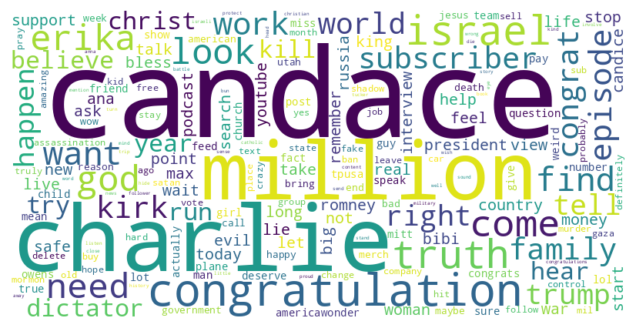

In [61]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)
plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

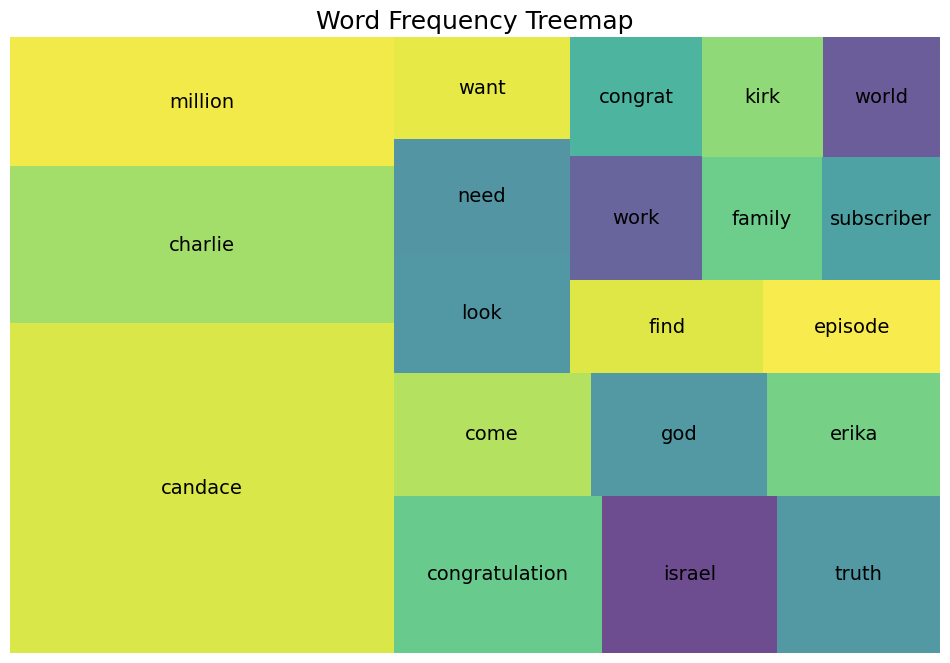

In [62]:
import squarify
plt.figure(figsize=(12, 8))

tree_show = word_counts.sort_values(ascending=False).head(20)
squarify.plot(sizes=tree_show.values,
              label=tree_show.index,
              alpha=0.8,
              text_kwargs={'fontsize': 14})

plt.title("Word Frequency Treemap", fontsize=18)
plt.axis("off")
plt.show()

#Topic Modeling - LDA

In [63]:
from gensim import corpora

dictionary = corpora.Dictionary(df_nlp["token_clean_lda"])

dictionary.filter_extremes(
    no_below=2,     # word must appear in at least 2 comments
    no_above=0.8    # remove words appearing in more than 80% of comments
)

corpus = [dictionary.doc2bow(tokens) for tokens in df_nlp["token_clean_lda"]]

In [64]:
print("Number of unique tokens:", len(dictionary))
print("Number of documents:", len(corpus))

Number of unique tokens: 3414
Number of documents: 4221


In [65]:
from gensim.models import LdaModel

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=3,
    random_state=99,
    passes=10,
    alpha="auto",
    per_word_topics=True
)

In [66]:
topics = lda_model.print_topics(num_topics=3, num_words=10)

for topic_id, words in topics:
    print(f"Topic {topic_id}: {words}")

Topic 0: 0.048*"candace" + 0.028*"charlie" + 0.016*"congratulation" + 0.012*"million" + 0.011*"truth" + 0.009*"erika" + 0.009*"come" + 0.008*"max" + 0.006*"want" + 0.006*"god"
Topic 1: 0.015*"million" + 0.012*"congrat" + 0.010*"israel" + 0.008*"family" + 0.008*"subscriber" + 0.008*"trump" + 0.007*"support" + 0.006*"look" + 0.005*"god" + 0.005*"evil"
Topic 2: 0.062*"candace" + 0.020*"dictator" + 0.020*"ana" + 0.018*"congrats" + 0.012*"wait" + 0.012*"look" + 0.011*"mil" + 0.011*"president" + 0.009*"owens" + 0.008*"wow"


In [67]:
def get_dominant_topic(bow):
    topic_probs = lda_model.get_document_topics(bow)

    if len(topic_probs) == 0:
        return None, 0

    dominant_topic, topic_score = max(topic_probs, key=lambda x: x[1])
    return dominant_topic, topic_score


dominant_topics = [get_dominant_topic(bow) for bow in corpus]

df_nlp["topic_id"] = [topic[0] for topic in dominant_topics]
df_nlp["topic_score"] = [topic[1] for topic in dominant_topics]

df_nlp[["clean_comment", "token_clean", "topic_id", "topic_score"]].head()

,clean_comment,token_clean,topic_id,topic_score
0,It did! It was about her being president.,[president],2,0.535482
1,"Hey Candace, followers: what happened to those...","[hey, candace, follower, happen, egyptian, plane]",0,0.919854
2,,[],0,0.506780
3,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE AN...,"[interview, proof, people, stand.]",0,0.816749
4,"CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A...","[congrats, candace, million, truth, seeker, aw...",0,0.764413


In [68]:
def create_topic_keywords_df(lda_model, num_topics=3, topn=8):
    topic_rows = []

    for topic_id in range(num_topics):
        words = lda_model.show_topic(topic_id, topn=topn)
        keywords = [word for word, weight in words]

        topic_rows.append({
            "topic_id": topic_id,
            "topic_keywords": ", ".join(keywords),
            "topic_name": " / ".join(keywords[:3])
        })

    return pd.DataFrame(topic_rows)

In [69]:
topic_keywords_df = create_topic_keywords_df(
    lda_model,
    num_topics=3,
    topn=8
)

topic_keywords_df

,topic_id,topic_keywords,topic_name
0,0,"candace, charlie, congratulation, million, tru...",candace / charlie / congratulation
1,1,"million, congrat, israel, family, subscriber, ...",million / congrat / israel
2,2,"candace, dictator, ana, congrats, wait, look, ...",candace / dictator / ana


In [70]:
topic_summary = (
    df_nlp["topic_id"]
    .value_counts()
    .reset_index()
)

topic_summary.columns = ["topic_id", "comment_count"]

topic_summary = topic_summary.merge(
    topic_keywords_df,
    on="topic_id",
    how="left"
)

topic_summary

,topic_id,comment_count,topic_keywords,topic_name
0,0,2355,"candace, charlie, congratulation, million, tru...",candace / charlie / congratulation
1,1,1288,"million, congrat, israel, family, subscriber, ...",million / congrat / israel
2,2,578,"candace, dictator, ana, congrats, wait, look, ...",candace / dictator / ana


In [71]:
import plotly.express as px

fig = px.bar(
    topic_summary,
    x="topic_name",
    y="comment_count",
    text="comment_count",
    title="Main Discussion Topics in YouTube Comments",
    labels={
        "topic_name": "Topic",
        "comment_count": "Number of Comments"
    }
)

fig.update_traces(textposition="outside")
fig.update_layout(xaxis_tickangle=-30)
fig.show()

#N-gram + TF-IDF

In [72]:
df_ngram = df_nlp.copy()

df_ngram["clean_text_for_model"] = df_ngram["token_clean"].apply(
    lambda tokens: " ".join(tokens)
)

df_ngram[["clean_comment", "token_clean", "clean_text_for_model"]].head()

,clean_comment,token_clean,clean_text_for_model
0,It did! It was about her being president.,[president],president
1,"Hey Candace, followers: what happened to those...","[hey, candace, follower, happen, egyptian, plane]",hey candace follower happen egyptian plane
2,,[],
3,ALL THESE INTERVIEWS ARE PROOF OF. 🤔🧐 WHERE AN...,"[interview, proof, people, stand.]",interview proof people stand.
4,"CONGRATS CANDACE ON 6 MILLION TRUTH SEEKERS, A...","[congrats, candace, million, truth, seeker, aw...",congrats candace million truth seeker awakened...


In [73]:
custom_stopwords = [
    "video", "people",
    "like", "say", "said", "know", "think", "see",
    "need", "make", "watch", "really", "would",
    "one", "get", "go", "also", "much", "love",
    "great", "good", "thank", "thanks"
]

In [74]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def get_top_ngrams(text_series, ngram_range=(2, 2), top_n=20, min_df=2, max_df=0.8):
    vectorizer = CountVectorizer(
        stop_words=custom_stopwords,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df
    )

    X = vectorizer.fit_transform(text_series)

    ngram_counts = X.sum(axis=0).A1
    ngram_names = vectorizer.get_feature_names_out()

    ngram_df = pd.DataFrame({
        "ngram": ngram_names,
        "count": ngram_counts
    })

    ngram_df = ngram_df.sort_values("count", ascending=False).head(top_n)

    return ngram_df

In [75]:
top_bigrams = get_top_ngrams(
    df_ngram["clean_text_for_model"],
    ngram_range=(2, 2),
    top_n=20,
    min_df=2,
    max_df=0.8
)

top_bigrams

,ngram,count
415,charlie kirk,85
1357,million subscriber,69
458,christ king,68
548,congratulation candace,64
558,congratulation million,57
911,god bless,56
310,candace owens,52
260,candace dictator,46
1757,shadow ban,43
1385,mitt romney,42


In [76]:
top_trigrams = get_top_ngrams(
    df_ngram["clean_text_for_model"],
    ngram_range=(3, 3),
    top_n=20,
    min_df=2,
    max_df=0.8
)

top_trigrams

,ngram,count
37,boston consulting group,16
224,god bless family,14
135,congratulation million subscriber,10
54,candace dictator 2028,9
196,evil wicked hearted,6
65,candace million subscriber,6
125,congratulation candace million,6
271,jesus christ king,6
246,hell life live,6
386,reach million subscriber,5


In [77]:
import plotly.express as px

fig = px.bar(
    top_bigrams.sort_values("count"),
    x="count",
    y="ngram",
    orientation="h",
    text="count",
    title="Top Repeated 2-Word Phrases in YouTube Comments",
    labels={
        "count": "Frequency",
        "ngram": "Phrase"
    }
)

fig.update_traces(textposition="outside")
fig.show()

In [78]:
fig = px.bar(
    top_trigrams.sort_values("count"),
    x="count",
    y="ngram",
    orientation="h",
    text="count",
    title="Top Repeated 3-Word Phrases in YouTube Comments",
    labels={
        "count": "Frequency",
        "ngram": "Phrase"
    }
)

fig.update_traces(textposition="outside")
fig.show()

In [79]:
from sklearn.feature_extraction.text import TfidfVectorizer

def get_top_tfidf_terms(text_series, ngram_range=(1, 2), top_n=25, min_df=2, max_df=0.8):
    vectorizer = TfidfVectorizer(
        stop_words=custom_stopwords,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df
    )

    X = vectorizer.fit_transform(text_series)

    tfidf_scores = X.mean(axis=0).A1
    terms = vectorizer.get_feature_names_out()

    tfidf_df = pd.DataFrame({
        "term": terms,
        "tfidf_score": tfidf_scores
    })

    tfidf_df = tfidf_df.sort_values("tfidf_score", ascending=False).head(top_n)

    return tfidf_df

In [80]:
top_tfidf = get_top_tfidf_terms(
    df_ngram["clean_text_for_model"],
    ngram_range=(1, 2),
    top_n=25,
    min_df=2,
    max_df=0.8
)

top_tfidf

,term,tfidf_score
792,candace,0.043650
1309,congratulation,0.027449
3351,million,0.024896
1028,charlie,0.015968
1287,congrat,0.011830
5241,truth,0.010061
2802,israel,0.008667
1207,come,0.008592
1651,dictator,0.008325
3135,look,0.008316


In [81]:
fig = px.bar(
    top_tfidf.sort_values("tfidf_score"),
    x="tfidf_score",
    y="term",
    orientation="h",
    text="tfidf_score",
    title="Top TF-IDF Keywords and Phrases",
    labels={
        "tfidf_score": "Average TF-IDF Score",
        "term": "Keyword / Phrase"
    }
)

fig.update_traces(texttemplate="%{text:.3f}", textposition="outside")
fig.show()